In [1]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from collections import Counter
import os


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [2]:
# load data
df = pd.read_csv('../outputs/cleaned_text_data.csv')

# word cloud

In [3]:
option2_text = ' '.join(df[df['religious_group'] == 'option2']['cleaned_content'].dropna())
option1_text = ' '.join(df[df['religious_group'] == 'option1']['cleaned_content'].dropna())

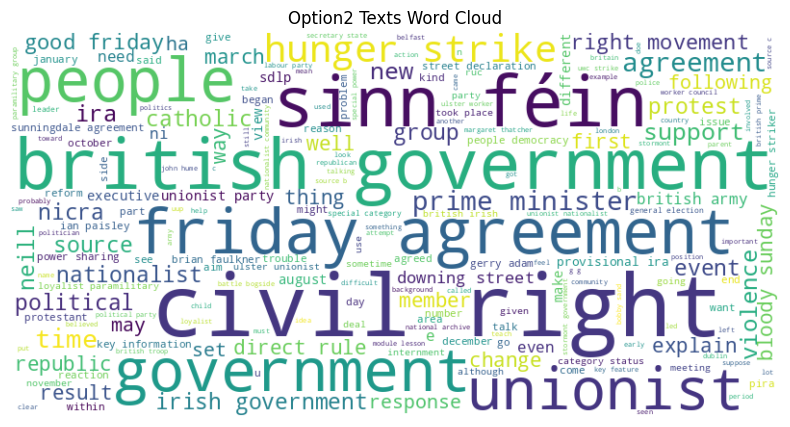

In [4]:
# Option2 word cloud
wc_option2 = WordCloud(width=800, height=400, background_color='white').generate(option2_text)
plt.figure(figsize=(10, 5))
plt.imshow(wc_option2, interpolation='bilinear')
plt.axis('off')
plt.title('Option2 Texts Word Cloud')
plt.show()

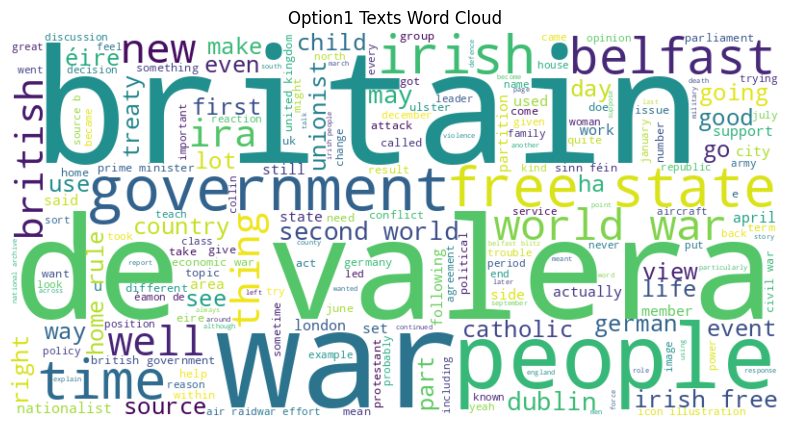

In [5]:
# Option1 word cloud
wc_option1 = WordCloud(width=800, height=400, background_color='white').generate(option1_text)
plt.figure(figsize=(10, 5))
plt.imshow(wc_option1, interpolation='bilinear')
plt.axis('off')
plt.title('Option1 Texts Word Cloud')
plt.show()

# TFIDF


In [6]:
# Debug: Check what's in the texts
print("\n=== DEBUG INFO ===")
if len(option2_text) > 0:
    print(f"Option2 text sample: {option2_text[:200]}")
    print(f"Option2 text length: {len(option2_text)}")
else:
    print("No Option2 text found!")

if len(option1_text) > 0:
    print(f"Option1 text sample: {option1_text[:200]}")
    print(f"Option1 text length: {len(option1_text)}")
else:
    print("No Option1 text found!")




=== DEBUG INFO ===
Option2 text sample: relation republic emergence development established government act act partitioned county southern later became irish free state population reacted new arrangement unionist mostly protestant delighted
Option2 text length: 1560377
Option1 text sample: e okay place since mean taught sort sector recently since eotas young people whose mainstream place broken social emotional difficulty taught belfast lisburn spent working outdoor pursuit instructor d
Option1 text length: 1205619


In [7]:
# Function to get top TF-IDF weighted n-grams
def get_top_tfidf_ngrams(text, ngram_range=(1, 1), top_n=20):
    """Get top n-grams based on TF-IDF scores"""
    
    vectorizer = TfidfVectorizer(max_features=1000, ngram_range=ngram_range)
    
    # Debug: check if we have any content
    print(f"Text length: {len(text)}")
    print(f"First 200 characters: {text[:200]}")
    
    # Check if text is mostly whitespace or empty
    if len(text.strip()) == 0:
        print("Warning: Text is empty or only whitespace!")
        return []
    
    try:
        tfidf_matrix = vectorizer.fit_transform([text])
        feature_names = vectorizer.get_feature_names_out()
        
        print(f"Number of features found: {len(feature_names)}")
        if len(feature_names) > 0:
            print(f"First 10 features: {feature_names[:10]}")
        
        if len(feature_names) == 0:
            print("Warning: No features found. Trying without stopwords...")
            vectorizer = TfidfVectorizer(max_features=1000, ngram_range=ngram_range)
            tfidf_matrix = vectorizer.fit_transform([text])
            feature_names = vectorizer.get_feature_names_out()
            print(f"Features without stopwords: {len(feature_names)}")
        
        # Get TF-IDF scores
        tfidf_sums = np.array(tfidf_matrix.sum(axis=0)).flatten()
        top_indices = tfidf_sums.argsort()[-top_n:][::-1]
        top_ngrams = [(feature_names[i], tfidf_sums[i]) for i in top_indices]
        return top_ngrams
        
    except ValueError as e:
        print(f"Error in TF-IDF processing: {e}")
        print("Trying without any stopwords...")
        vectorizer = TfidfVectorizer(max_features=1000, ngram_range=ngram_range)
        tfidf_matrix = vectorizer.fit_transform([text])
        feature_names = vectorizer.get_feature_names_out()
        
        # Get TF-IDF scores
        tfidf_sums = np.array(tfidf_matrix.sum(axis=0)).flatten()
        top_indices = tfidf_sums.argsort()[-top_n:][::-1]
        top_ngrams = [(feature_names[i], tfidf_sums[i]) for i in top_indices]
        return top_ngrams

In [8]:
# Analyze Option2 texts
print("\n=== OPTION2 TEXTS ANALYSIS ===")

# TF-IDF for unigrams
print("Building TF-IDF for Option2 texts...")
option2_top_terms = get_top_tfidf_ngrams(option2_text, ngram_range=(1, 1), top_n=20)

print("\nTop 20 terms in Option2 texts:")
for term, score in option2_top_terms:
    print(f"{term}: {score:.4f}")

# TF-IDF for bigrams
option2_top_bigrams = get_top_tfidf_ngrams(option2_text, ngram_range=(2, 2), top_n=20)

print("\nTop 20 bigrams in Option2 texts:")
for bigram, score in option2_top_bigrams:
    print(f"{bigram}: {score:.4f}")



=== OPTION2 TEXTS ANALYSIS ===
Building TF-IDF for Option2 texts...
Text length: 1560377
First 200 characters: relation republic emergence development established government act act partitioned county southern later became irish free state population reacted new arrangement unionist mostly protestant delighted
Number of features found: 1000
First 10 features: ['able' 'accept' 'accepted' 'accessibility' 'account' 'achieve' 'achieved'
 'across' 'act' 'action']

Top 20 terms in Option2 texts:
government: 0.2700
unionist: 0.2404
agreement: 0.2295
british: 0.1877
ira: 0.1504
nationalist: 0.1499
people: 0.1474
party: 0.1371
right: 0.1349
irish: 0.1322
strike: 0.1174
new: 0.1170
violence: 0.1156
source: 0.1145
march: 0.1133
political: 0.1121
support: 0.1108
civil: 0.1075
catholic: 0.1037
may: 0.0996
Text length: 1560377
First 200 characters: relation republic emergence development established government act act partitioned county southern later became irish free state population reacted new 

In [9]:
# Analyze Option1 texts
print("\n=== OPTION1 TEXTS ANALYSIS ===")

# TF-IDF for unigrams
print("Building TF-IDF for Option1 texts...")
option1_top_terms = get_top_tfidf_ngrams(option1_text, ngram_range=(1, 1), top_n=20)

print("\nTop 20 terms in Option1 texts:")
for term, score in option1_top_terms:
    print(f"{term}: {score:.4f}")

# TF-IDF for bigrams
option1_top_bigrams = get_top_tfidf_ngrams(option1_text, ngram_range=(2, 2), top_n=20)

print("\nTop 20 bigrams in Option1 texts:")
for bigram, score in option1_top_bigrams:
    print(f"{bigram}: {score:.4f}")


=== OPTION1 TEXTS ANALYSIS ===
Building TF-IDF for Option1 texts...
Text length: 1205619
First 200 characters: e okay place since mean taught sort sector recently since eotas young people whose mainstream place broken social emotional difficulty taught belfast lisburn spent working outdoor pursuit instructor d
Number of features found: 1000
First 10 features: ['ability' 'able' 'academy' 'accept' 'accepted' 'access' 'accessibility'
 'according' 'account' 'across']

Top 20 terms in Option1 texts:
war: 0.3465
irish: 0.3389
government: 0.1970
britain: 0.1935
british: 0.1877
people: 0.1787
state: 0.1715
belfast: 0.1425
de: 0.1283
valera: 0.1263
source: 0.1226
free: 0.1130
time: 0.1084
world: 0.1037
home: 0.0945
treaty: 0.0938
new: 0.0921
ira: 0.0788
catholic: 0.0777
dublin: 0.0759
Text length: 1205619
First 200 characters: e okay place since mean taught sort sector recently since eotas young people whose mainstream place broken social emotional difficulty taught belfast lisburn spent worki